# N-Body Gravity: Barnes-Hut Solver

Validates `nbody.py`'s `barnes_hut_accel` (a quadtree with the standard
opening-angle criterion `cell_size / distance < theta`, approximating a
distant, sufficiently "small-looking" cluster of particles as a single
point mass at its center of mass) against the reference `pairwise_accel`
from `Validation.ipynb`:

1. **Convergence**: force error vs. `theta`, confirming it -> 0 as
   `theta -> 0` (a bug anywhere in the tree-walk would show up as a floor
   on the error that doesn't vanish).
2. **Performance**: measured wall-clock scaling vs. `N` for both solvers.
3. **Consistency**: the Phase 1 Kepler and Lagrange-triangle cases,
   reproduced through Barnes-Hut.

The tree is still built in plain Python/numpy as flat arrays (that part
was never the bottleneck), but the force walk itself -- originally a
recursive Python object tree -- is now compiled with numba, since the
pure-Python version's constant factor was so large that Barnes-Hut never
actually beat vectorized numpy pairwise summation in wall-clock time
below N~5000-6000, despite its better asymptotic complexity. See
`N_Body_Gravity_Plan.md`'s "Performance optimization" section.

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import nbody as nb

os.makedirs('media', exist_ok=True)
rng = np.random.default_rng(0)

## Convergence: force error vs. theta

theta=0.00  mean relative force error=1.32e-15
theta=0.05  mean relative force error=7.62e-06
theta=0.10  mean relative force error=7.26e-05
theta=0.20  mean relative force error=9.21e-04
theta=0.30  mean relative force error=2.77e-03
theta=0.50  mean relative force error=1.57e-02
theta=0.70  mean relative force error=4.00e-02
theta=1.00  mean relative force error=8.80e-02
theta=1.50  mean relative force error=3.58e-01
PASS: error vanishes at theta=0 and grows monotonically with theta.


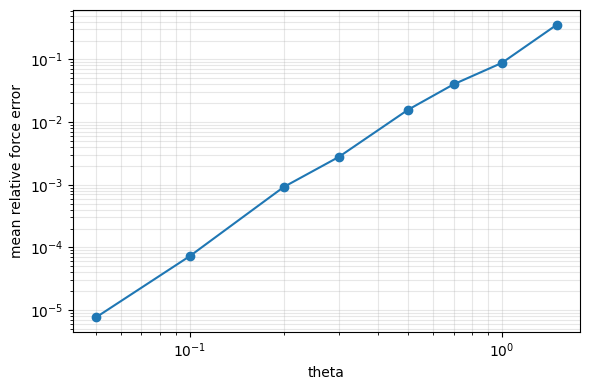

Chosen operating theta=0.5, mean error=1.57e-02


In [2]:
N = 200
pos = rng.uniform(-1, 1, size=(N, 2))
mass = rng.uniform(0.5, 2.0, size=N)
softening = 1e-3

a_direct = nb.pairwise_accel(pos, mass, G=1.0, softening=softening)
thetas = np.array([0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5])
errs = []
for theta in thetas:
    a_bh = nb.barnes_hut_accel(pos, mass, G=1.0, softening=softening, theta=theta)
    rel_err = np.linalg.norm(a_bh - a_direct, axis=-1) / np.linalg.norm(a_direct, axis=-1)
    errs.append(rel_err.mean())
errs = np.array(errs)
for th, e in zip(thetas, errs):
    print(f'theta={th:.2f}  mean relative force error={e:.2e}')

assert errs[0] < 1e-10, 'theta=0 (no approximation at all) should reproduce direct summation exactly'
assert np.all(np.diff(errs) >= -1e-12), 'error should grow monotonically with theta'
print('PASS: error vanishes at theta=0 and grows monotonically with theta.')

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(thetas[1:], errs[1:], 'o-')
ax.set_xlabel('theta'); ax.set_ylabel('mean relative force error'); ax.grid(alpha=0.3, which='both')
fig.tight_layout()
fig.savefig('media/barnes_hut_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

theta_op = 0.5
print(f'Chosen operating theta={theta_op}, mean error={errs[thetas == theta_op][0]:.2e}')
assert errs[thetas == theta_op][0] < 0.02, 'operating theta is not accurate enough'

## Performance: wall-clock scaling vs. N

N=  100  pairwise=0.0006s
N=  200  pairwise=0.0017s
N=  400  pairwise=0.0081s
N=  800  pairwise=0.0308s
N= 1600  pairwise=0.1159s


N= 3200  pairwise=0.4978s


N= 6400  pairwise=2.6608s
N=  100  barnes_hut=0.0036s
N=  200  barnes_hut=0.0073s
N=  400  barnes_hut=0.0136s
N=  800  barnes_hut=0.0180s
N= 1600  barnes_hut=0.0518s
N= 3200  barnes_hut=0.1104s


N= 6400  barnes_hut=0.2063s


N=12800  barnes_hut=0.3944s


N=25600  barnes_hut=0.7881s
fitted power-law slope: pairwise ~ N^2.03, barnes-hut (numba) ~ N^0.98
PASS: barnes-hut scales sub-quadratically, distinctly better than the O(N^2) pairwise solver.
crossover: barnes-hut is faster than pairwise in absolute wall-clock time starting at N=800 (compare to the ~5000-6000 crossover before the numba rewrite -- the tree-walk's constant factor, not its asymptotic complexity, was the thing holding it back).


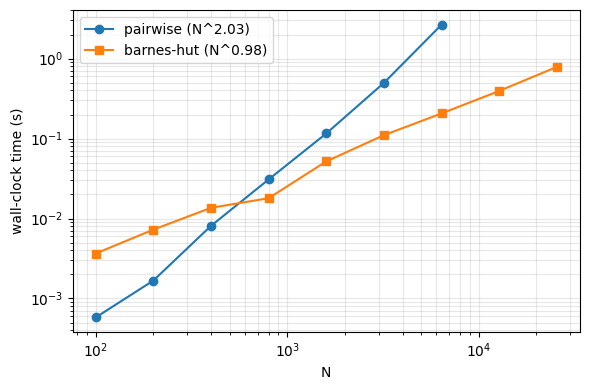

In [3]:
# pairwise is O(N^2), so it isn't pushed as far as barnes-hut here -- it would
# take minutes per call well before N=25600 (barnes-hut takes well under a second there).
Ns_pairwise = [100, 200, 400, 800, 1600, 3200, 6400]
Ns_bh = [100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600]

t_pairwise = []
for N in Ns_pairwise:
    pos = rng.uniform(-1, 1, size=(N, 2))
    mass = rng.uniform(0.5, 2.0, size=N)
    t0 = time.perf_counter(); nb.pairwise_accel(pos, mass); t_pairwise.append(time.perf_counter() - t0)
    print(f'N={N:5d}  pairwise={t_pairwise[-1]:.4f}s')

t_bh = []
for N in Ns_bh:
    pos = rng.uniform(-1, 1, size=(N, 2))
    mass = rng.uniform(0.5, 2.0, size=N)
    t0 = time.perf_counter(); nb.barnes_hut_accel(pos, mass, theta=theta_op); t_bh.append(time.perf_counter() - t0)
    print(f'N={N:5d}  barnes_hut={t_bh[-1]:.4f}s')

Ns_pairwise, Ns_bh = np.array(Ns_pairwise), np.array(Ns_bh)
slope_pairwise = np.polyfit(np.log(Ns_pairwise), np.log(t_pairwise), 1)[0]
slope_bh = np.polyfit(np.log(Ns_bh), np.log(t_bh), 1)[0]
print(f'fitted power-law slope: pairwise ~ N^{slope_pairwise:.2f}, barnes-hut (numba) ~ N^{slope_bh:.2f}')
assert slope_pairwise > 1.7, 'pairwise should scale close to O(N^2)'
assert slope_bh < slope_pairwise - 0.3, 'barnes-hut should scale sub-quadratically, distinctly better than pairwise'
print('PASS: barnes-hut scales sub-quadratically, distinctly better than the O(N^2) pairwise solver.')

# crossover: the smallest N (in the overlapping range) where barnes-hut wins outright
common = [n for n in Ns_bh if n in Ns_pairwise]
crossover = next((n for n in common if t_bh[list(Ns_bh).index(n)] < t_pairwise[list(Ns_pairwise).index(n)]), None)
print(f'crossover: barnes-hut is faster than pairwise in absolute wall-clock time starting at N={crossover} '
      '(compare to the ~5000-6000 crossover before the numba rewrite -- the tree-walk\'s constant factor, '
      'not its asymptotic complexity, was the thing holding it back).')

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(Ns_pairwise, t_pairwise, 'o-', label=f'pairwise (N^{slope_pairwise:.2f})')
ax.loglog(Ns_bh, t_bh, 's-', label=f'barnes-hut (N^{slope_bh:.2f})')
ax.set_xlabel('N'); ax.set_ylabel('wall-clock time (s)'); ax.legend(); ax.grid(alpha=0.3, which='both')
fig.tight_layout()
fig.savefig('media/barnes_hut_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

## Consistency: Phase 1 cases reproduced through Barnes-Hut

In [4]:
# Two-body Kepler orbit (same setup as Validation.ipynb)
G = 1.0
m1, m2 = 1.0, 1.0
M = m1 + m2
r0 = 1.0
v_circ = np.sqrt(G * M / r0)
v_rel = 0.8 * v_circ
eps = v_rel**2 / 2 - G * M / r0
a = -G * M / (2 * eps)
h = r0 * v_rel
e = np.sqrt(1 - h**2 / (G * M * a))
T = 2 * np.pi * np.sqrt(a**3 / (G * M))
r_min_analytic, r_max_analytic = a * (1 - e), a * (1 + e)

mass2 = np.array([m1, m2])
pos0_2 = np.array([[-r0 * m2 / M, 0.0], [r0 * m1 / M, 0.0]])
vel0_2 = np.array([[0.0, -v_rel * m2 / M], [0.0, v_rel * m1 / M]])

bh_theta05 = lambda pos, mass, G, softening: nb.barnes_hut_accel(pos, mass, G, softening, theta=theta_op)

dt = T / 2000
n_steps = int(4 * T / dt)
pos_t, vel_t = nb.integrate(pos0_2, vel0_2, mass2, dt, n_steps, bh_theta05, G=G, softening=1e-6)
rel = pos_t[:, 1, :] - pos_t[:, 0, :]
r_t = np.linalg.norm(rel, axis=-1)
err_min = abs(r_t.min() - r_min_analytic) / r_min_analytic
err_max = abs(r_t.max() - r_max_analytic) / r_max_analytic
print(f'Kepler via Barnes-Hut: periapsis error={err_min:.2e}  apoapsis error={err_max:.2e}')
assert err_min < 0.02 and err_max < 0.02, 'Barnes-Hut Kepler orbit does not match the analytic ellipse'
print('PASS: Barnes-Hut reproduces the two-body Kepler orbit.')

Kepler via Barnes-Hut: periapsis error=7.44e-06  apoapsis error=2.22e-16
PASS: Barnes-Hut reproduces the two-body Kepler orbit.


In [5]:
# Lagrange equilateral triangle (same setup as Validation.ipynb)
m = 1.0
s = 1.0
mass3 = np.array([m, m, m])
Omega = np.sqrt(G * 3 * m / s**3)
r_tri = s / np.sqrt(3)
T3 = 2 * np.pi / Omega
thetas3 = np.array([0, 2 * np.pi / 3, 4 * np.pi / 3])
pos0_3 = r_tri * np.stack([np.cos(thetas3), np.sin(thetas3)], axis=1)
vel0_3 = Omega * r_tri * np.stack([-np.sin(thetas3), np.cos(thetas3)], axis=1)

dt3 = T3 / 2000
n_steps3 = int(5 * T3 / dt3)
pos_t3, vel_t3 = nb.integrate(pos0_3, vel0_3, mass3, dt3, n_steps3, bh_theta05, G=G, softening=1e-6)
radius = np.linalg.norm(pos_t3, axis=-1)
err_r = np.max(np.abs(radius - r_tri)) / r_tri
print(f'Lagrange triangle via Barnes-Hut: max centroid-distance error={err_r:.2e}')
assert err_r < 0.02, 'Barnes-Hut does not preserve the equilateral configuration'
print('PASS: Barnes-Hut reproduces the Lagrange equilateral-triangle orbit.')

Lagrange triangle via Barnes-Hut: max centroid-distance error=5.05e-06
PASS: Barnes-Hut reproduces the Lagrange equilateral-triangle orbit.
